Make a plot of planetary radius as a function of equilibrium temperature and investigate whether there is a clear transition where inflation becomes significant.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import csv

In [54]:
temps = []
radii = []
names = []

with open("PSCompPars_2026.csv", newline='') as file:
    for line in file:
        if not line.startswith("#"):  # first non-metadata line
            header_line = line
            break

    reader = csv.DictReader(file, fieldnames=header_line.strip().split(","))
    # print(reader.fieldnames)

    for row in reader:
        if row["pl_eqt"] and row["pl_radj"]:
            temps.append(float(row["pl_eqt"]))
            radii.append(float(row["pl_radj"]))
            names.append(row["pl_name"])

In [51]:
combined = list(zip(temps, radii, names))
combined.sort()

temps_sorted, radii_sorted, names_sorted = zip(*combined)

In [52]:
def plot1(eqt, rad, names):
    plt.plot(eqt, rad, "-o")

    for x, y, name in zip(eqt, rad, names):
        # plt.annotate(name, (x, y), textcoords="offset points", xytext=(5,5))
        plt.text(x + 5, y + 0.01, name)

    plt.xlabel("Equilibrium Temperature (K)")
    plt.ylabel("Planetary Radius (J)")
    plt.title("10 Hot Jupiters")

    plt.show()


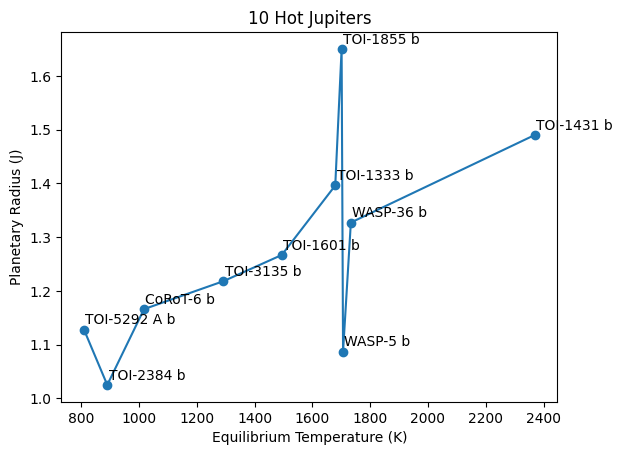

In [53]:
plot1(temps_sorted, radii_sorted, names_sorted)